# Interpretable vs Black Box Models on the Adult Dataset
### Predicting whether income exceeds $50K/year

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

print("Setup complete!")

Setup complete!


In [5]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

# Load train set
df_train = pd.read_csv('adult/adult.data', names=columns, sep=',\\s*',
                        engine='python', na_values='?')

# Load test set (skip first line, remove trailing '.' from labels)
df_test = pd.read_csv('adult/adult.test', names=columns, sep=',\\s*',
                       engine='python', na_values='?', skiprows=1)
df_test['income'] = df_test['income'].str.rstrip('.')

# Combine for exploration
df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Train: {df_train.shape}, Test: {df_test.shape}, Total: {df.shape}")
print(f"\nTarget distribution:\n{df['income'].value_counts(normalize=True).round(3)}")
df.head()

Train: (32561, 15), Test: (16281, 15), Total: (48842, 15)

Target distribution:
income
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Data Exploration


In [6]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal rows with at least one missing: {df.isnull().any(axis=1).sum()} / {len(df)}")

# Feature types
categorical_cols = df.select_dtypes(include='object').columns.drop('income').tolist()
numerical_cols = df.select_dtypes(include='number').columns.tolist()

print(f"\nCategorical ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical ({len(numerical_cols)}): {numerical_cols}")

Missing values per column:
workclass         2799
occupation        2809
native_country     857
dtype: int64

Total rows with at least one missing: 3620 / 48842

Categorical (8): ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
Numerical (6): ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


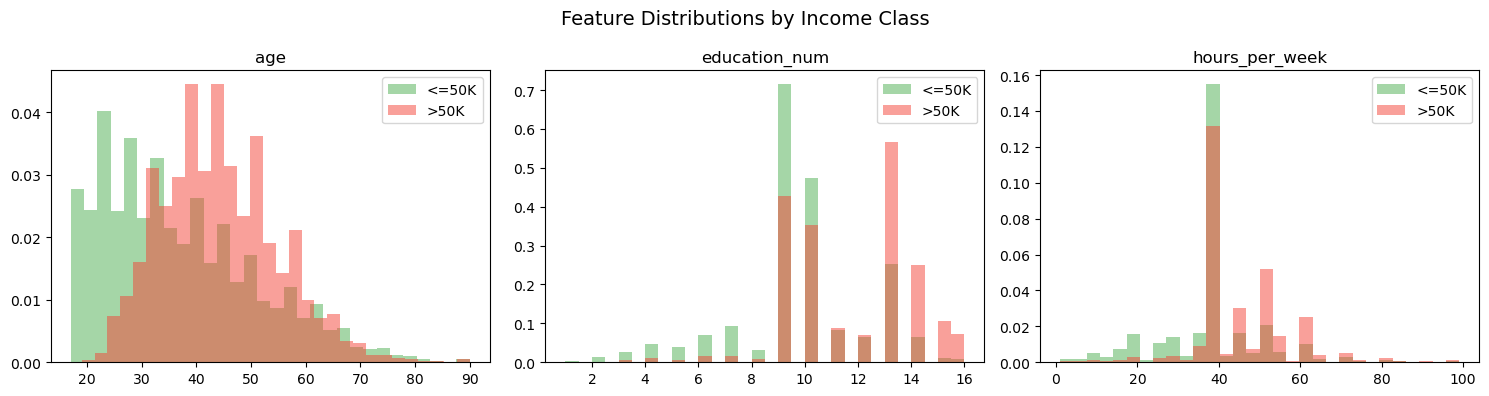

In [7]:
# Distribution of key numerical features by income
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['age', 'education_num', 'hours_per_week']):
    for label, color in [('<=50K', '#4CAF50'), ('>50K', '#F44336')]:
        subset = df[df['income'] == label][col].dropna()
        ax.hist(subset, bins=30, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(col)
    ax.legend()

plt.suptitle('Feature Distributions by Income Class', fontsize=14)
plt.tight_layout()
plt.show()

## Data Cleaning & Preprocessing

We drop missing values (small proportion), encode the target as 0/1, one-hot encode categorical features, and scale numerical ones. We use the original train/test split provided by UCI.

In [8]:
# Drop missing values
df_train = df_train.dropna()
df_test = df_test.dropna()
print(f"After dropping NAs — Train: {len(df_train)}, Test: {len(df_test)}")

# Encode target
df_train['income'] = (df_train['income'] == '>50K').astype(int)
df_test['income'] = (df_test['income'] == '>50K').astype(int)

# One-hot encode — fit on train, align test to same columns
df_train_enc = pd.get_dummies(df_train, columns=categorical_cols, drop_first=True)
df_test_enc = pd.get_dummies(df_test, columns=categorical_cols, drop_first=True)

# Align columns (test might miss rare categories)
df_test_enc = df_test_enc.reindex(columns=df_train_enc.columns, fill_value=0)

# Split X / y
X_train = df_train_enc.drop('income', axis=1)
y_train = df_train_enc['income']
X_test = df_test_enc.drop('income', axis=1)
y_test = df_test_enc['income']

# Scale numerical features (for logistic regression)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Features: {X_train.shape[1]}")
print(f"Train target balance: {y_train.mean():.3f} (proportion >50K)")
print(f"Test target balance:  {y_test.mean():.3f}")

After dropping NAs — Train: 30162, Test: 15060
Features: 96
Train target balance: 0.249 (proportion >50K)
Test target balance:  0.246


## Logistic Regression

Fully interpretable: each coefficient tells you exactly how much a feature contributes. This is the kind of model Rudin advocates — you can inspect, debug, and trust it.

In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression (Interpretable) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"\n{classification_report(y_test, y_pred_lr)}")

=== Logistic Regression (Interpretable) ===
Accuracy: 0.8479
AUC-ROC:  0.9032

              precision    recall  f1-score   support

           0       0.88      0.93      0.90     11360
           1       0.73      0.60      0.66      3700

    accuracy                           0.85     15060
   macro avg       0.80      0.77      0.78     15060
weighted avg       0.84      0.85      0.84     15060



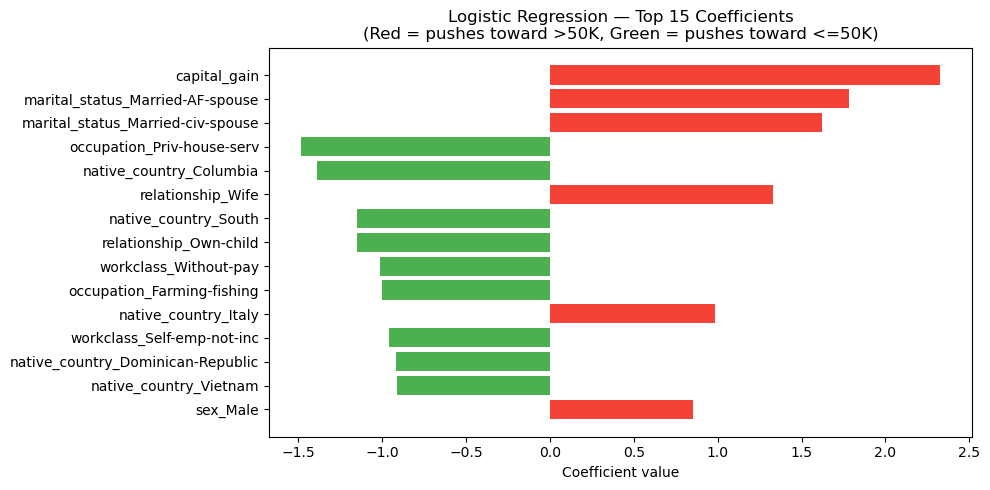

In [10]:
# Top 15 most influential coefficients
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#F44336' if c > 0 else '#4CAF50' for c in coef_df['coefficient']]
ax.barh(range(len(coef_df)), coef_df['coefficient'], color=colors)
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df['feature'])
ax.set_xlabel('Coefficient value')
ax.set_title('Logistic Regression — Top 15 Coefficients\n(Red = pushes toward >50K, Green = pushes toward <=50K)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Decision Tree 

A shallow decision tree limited to depth 5 — the logic can be read by a human. Analogous to the CORELS rule lists in Rudin's paper.

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)  # Trees don't need scaling

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("=== Decision Tree, depth=5 (Interpretable) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob_dt):.4f}")
print(f"\n{classification_report(y_test, y_pred_dt)}")

=== Decision Tree, depth=5 (Interpretable) ===
Accuracy: 0.8404
AUC-ROC:  0.8839

              precision    recall  f1-score   support

           0       0.85      0.96      0.90     11360
           1       0.78      0.49      0.60      3700

    accuracy                           0.84     15060
   macro avg       0.82      0.72      0.75     15060
weighted avg       0.83      0.84      0.83     15060



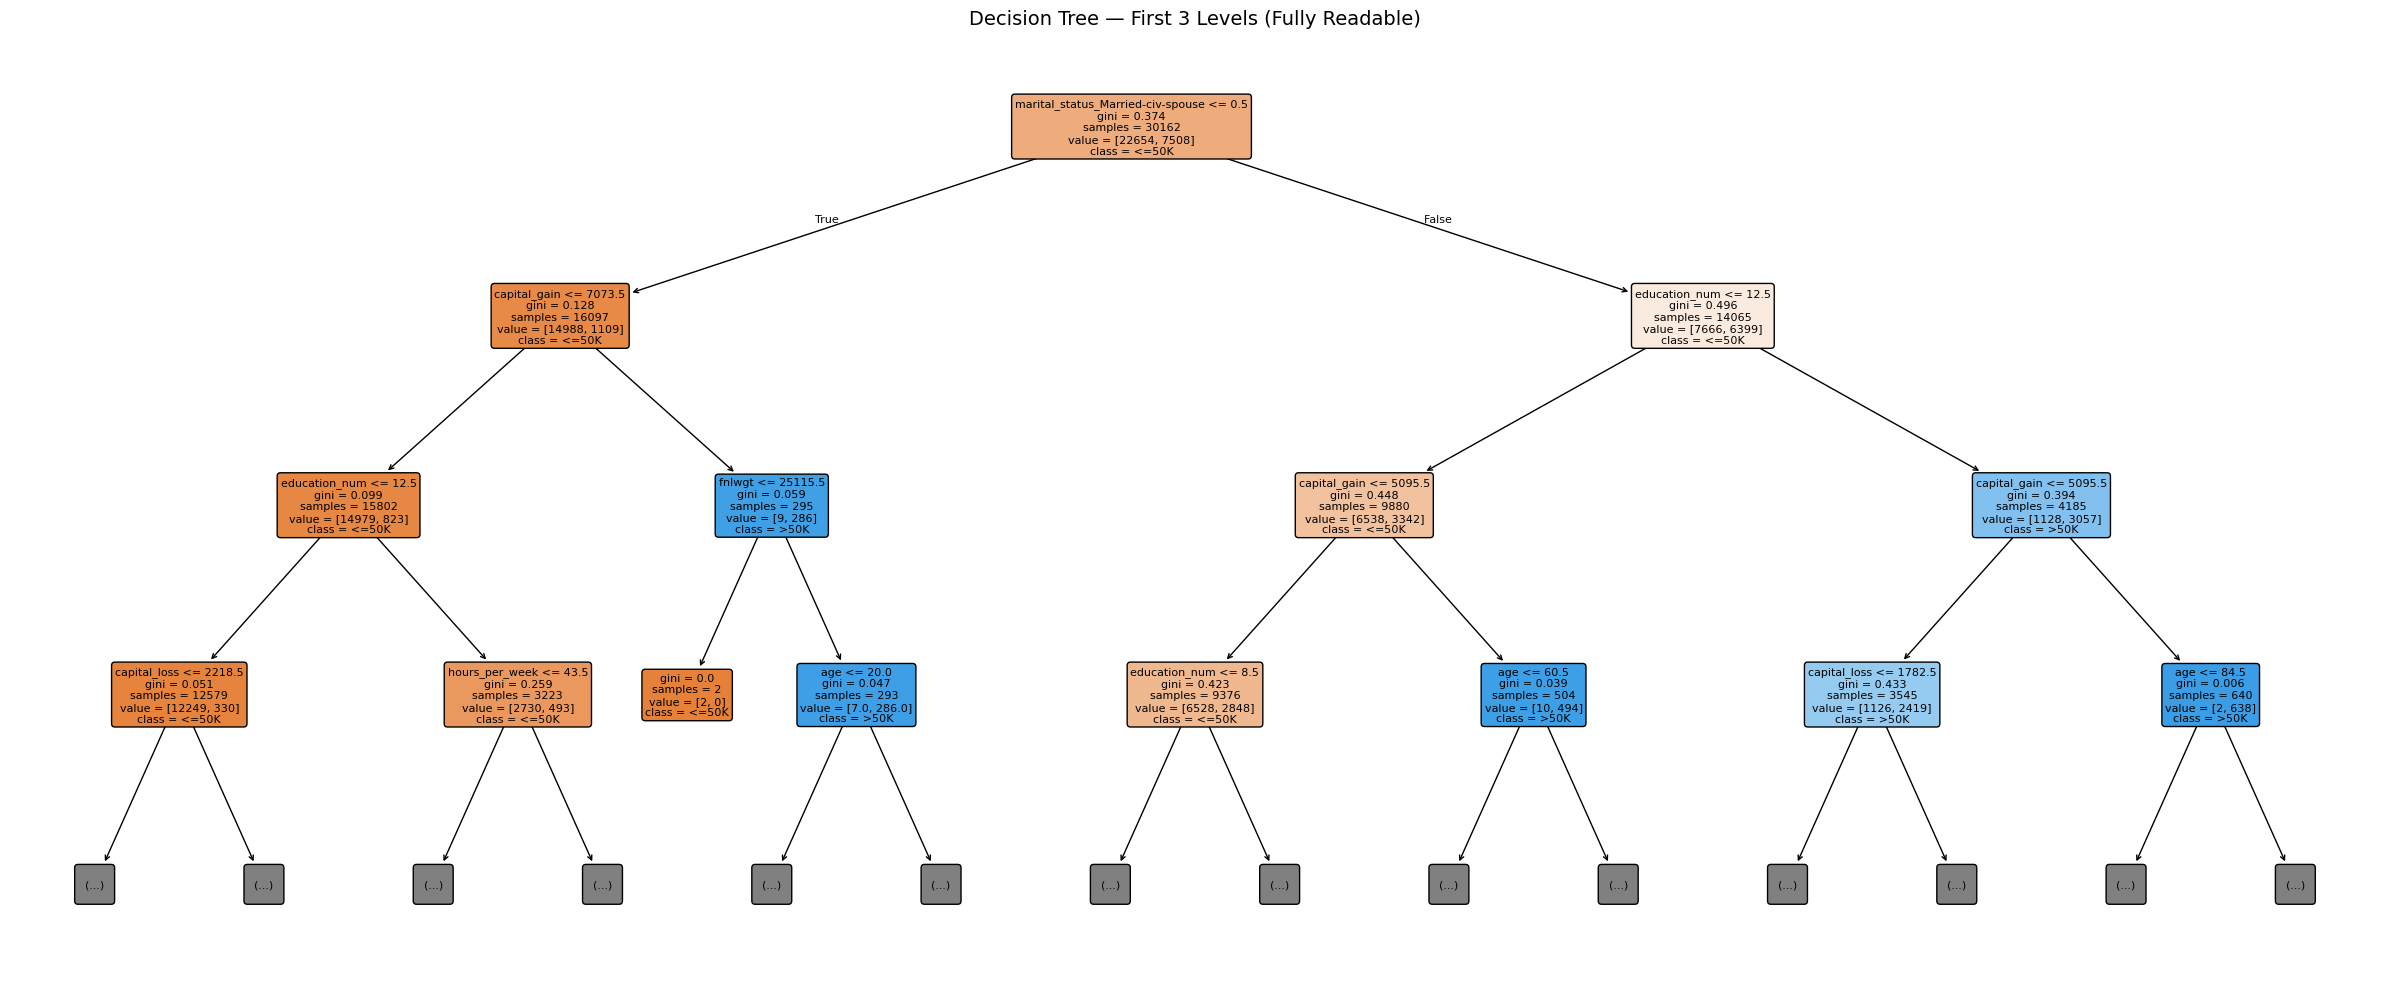

In [12]:
# Visualize the tree (first 3 levels for readability)
plt.figure(figsize=(24, 10))
plot_tree(dt, feature_names=X_train.columns, class_names=['<=50K', '>50K'],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Decision Tree — First 3 Levels (Fully Readable)", fontsize=14)
plt.tight_layout()
plt.show()

## Random Forest 

200 trees, each up to depth 15. No human can read 200 trees simultaneously — this is a black box. The question: how much accuracy does it gain?

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest (Black Box) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"\n{classification_report(y_test, y_pred_rf)}")

=== Random Forest (Black Box) ===
Accuracy: 0.8568
AUC-ROC:  0.9131

              precision    recall  f1-score   support

           0       0.87      0.95      0.91     11360
           1       0.79      0.57      0.66      3700

    accuracy                           0.86     15060
   macro avg       0.83      0.76      0.79     15060
weighted avg       0.85      0.86      0.85     15060



## Gradient Boosting

Typically the strongest performer on tabular data. Our "best accuracy" benchmark.

In [14]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                 learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print("=== Gradient Boosting (Black Box) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob_gb):.4f}")
print(f"\n{classification_report(y_test, y_pred_gb)}")

=== Gradient Boosting (Black Box) ===
Accuracy: 0.8708
AUC-ROC:  0.9264

              precision    recall  f1-score   support

           0       0.90      0.94      0.92     11360
           1       0.78      0.66      0.72      3700

    accuracy                           0.87     15060
   macro avg       0.84      0.80      0.82     15060
weighted avg       0.87      0.87      0.87     15060



## Model Comparison

In [15]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree (d=5)',
              'Random Forest', 'Gradient Boosting'],
    'Type': ['Interpretable', 'Interpretable', 'Black Box', 'Black Box'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_dt),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_gb)],
    'AUC-ROC': [roc_auc_score(y_test, y_prob_lr),
                roc_auc_score(y_test, y_prob_dt),
                roc_auc_score(y_test, y_prob_rf),
                roc_auc_score(y_test, y_prob_gb)]
})

print(results.to_string(index=False))

gap = results['AUC-ROC'].max() - results.loc[results['Type']=='Interpretable', 'AUC-ROC'].max()
print(f"\n→ AUC gap (best black box vs best interpretable): {gap:.4f}")

              Model          Type  Accuracy  AUC-ROC
Logistic Regression Interpretable  0.847875 0.903208
Decision Tree (d=5) Interpretable  0.840372 0.883942
      Random Forest     Black Box  0.856839 0.913149
  Gradient Boosting     Black Box  0.870784 0.926393

→ AUC gap (best black box vs best interpretable): 0.0232


Logistic Regression reaches 0.903, while Gradient Boosting reaches 0.926. On a real high-stakes decision, is a 2.3% AUC improvement worth losing transparency?

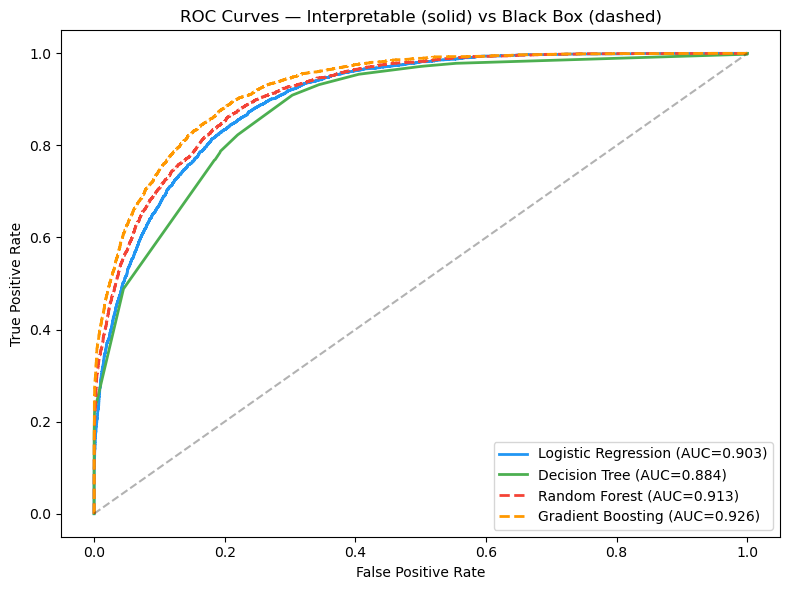

In [16]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob, color, ls in [
    ('Logistic Regression', y_prob_lr, '#2196F3', '-'),
    ('Decision Tree', y_prob_dt, '#4CAF50', '-'),
    ('Random Forest', y_prob_rf, '#F44336', '--'),
    ('Gradient Boosting', y_prob_gb, '#FF9800', '--'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
            label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Interpretable (solid) vs Black Box (dashed)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

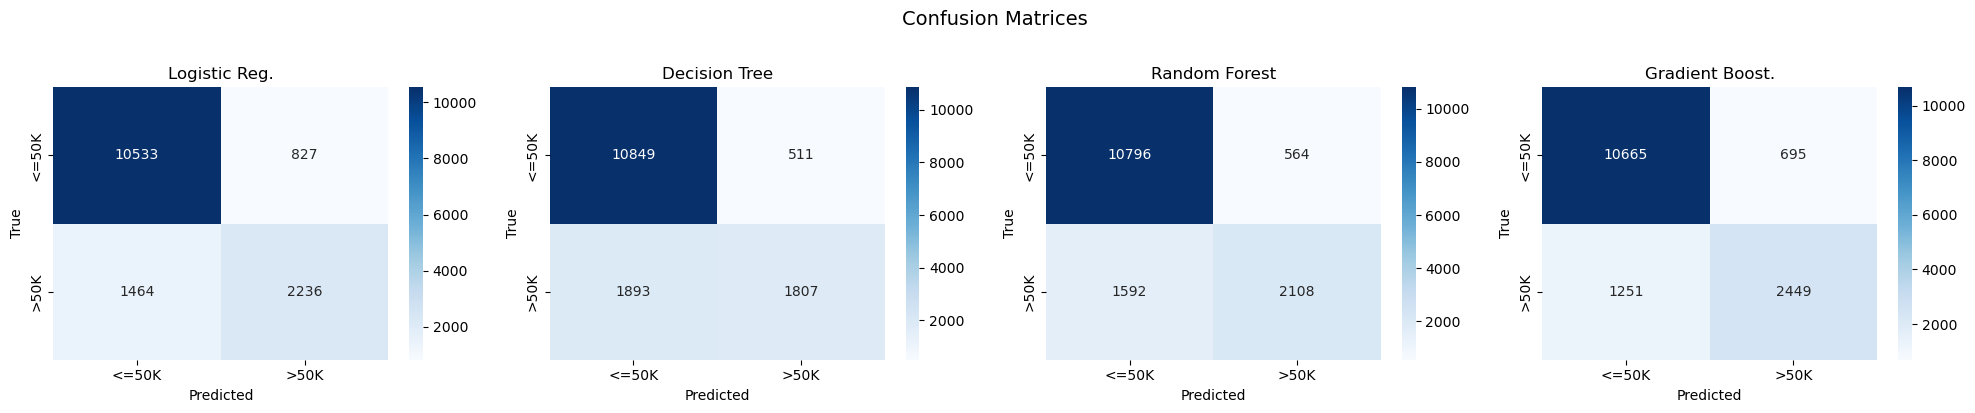

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, name, y_pred in zip(axes,
    ['Logistic Reg.', 'Decision Tree', 'Random Forest', 'Gradient Boost.'],
    [y_pred_lr, y_pred_dt, y_pred_rf, y_pred_gb]):

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    ax.set_title(name)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Explainable Boosting Machine (InterpretML)

The EBM is a **glass-box** model: a generalized additive model with automatic interaction detection. It achieves black-box-level accuracy while being fully transparent.

This is exactly the kind of model Rudin advocates: inherently interpretable, no post hoc explanation needed.

In [18]:
from interpret.glassbox import ExplainableBoostingClassifier

ebm = ExplainableBoostingClassifier(random_state=42)
ebm.fit(X_train, y_train)  # EBM handles scaling internally

y_pred_ebm = ebm.predict(X_test)
y_prob_ebm = ebm.predict_proba(X_test)[:, 1]

print("=== Explainable Boosting Machine (Glass-Box) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ebm):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob_ebm):.4f}")
print(f"\n{classification_report(y_test, y_pred_ebm)}")

=== Explainable Boosting Machine (Glass-Box) ===
Accuracy: 0.8704
AUC-ROC:  0.9266

              precision    recall  f1-score   support

           0       0.90      0.94      0.92     11360
           1       0.77      0.67      0.72      3700

    accuracy                           0.87     15060
   macro avg       0.83      0.80      0.82     15060
weighted avg       0.87      0.87      0.87     15060



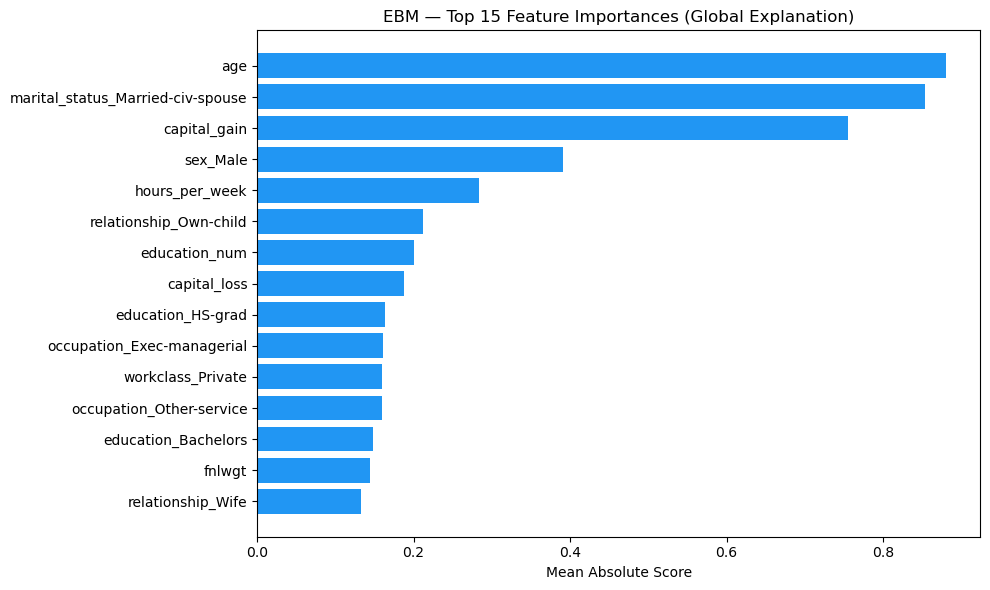

In [19]:
# EBM global feature importances
importances = ebm.term_importances()
names = ebm.term_names_

sorted_idx = np.argsort(importances)[-15:]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(sorted_idx)), importances[sorted_idx], color='#2196F3')
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([names[i] for i in sorted_idx])
ax.set_xlabel('Mean Absolute Score')
ax.set_title('EBM — Top 15 Feature Importances (Global Explanation)')
plt.tight_layout()
plt.show()

### EBM Shape Functions

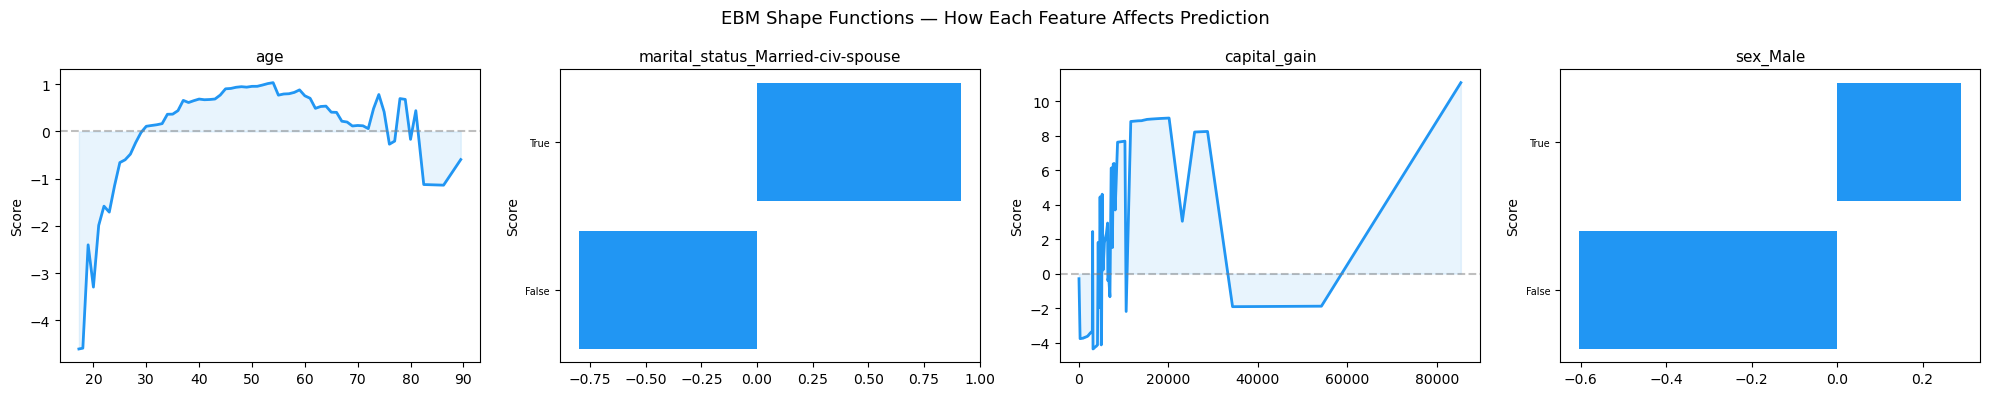

In [21]:
# EBM shape functions for top 4 features
ebm_global = ebm.explain_global()

importances = ebm.term_importances()
names = ebm.term_names_
top_4_idx = np.argsort(importances)[-4:][::-1]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, feat_idx in zip(axes, top_4_idx):
    data = ebm_global.data(feat_idx)
    if 'names' in data and 'scores' in data:
        x_vals = data['names']
        y_vals = data['scores']
        
        # Handle length mismatch (bin edges vs bin centers)
        if len(x_vals) == len(y_vals) + 1:
            # x_vals are bin edges — convert to bin centers
            x_vals = [(x_vals[i] + x_vals[i+1]) / 2 for i in range(len(y_vals))]
        
        if len(x_vals) == len(y_vals):
            if isinstance(x_vals[0], (int, float, np.integer, np.floating)):
                ax.plot(x_vals, y_vals, color='#2196F3', linewidth=2)
                ax.fill_between(x_vals, y_vals, alpha=0.1, color='#2196F3')
                ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            else:
                ax.barh(range(len(x_vals)), y_vals, color='#2196F3')
                ax.set_yticks(range(len(x_vals)))
                ax.set_yticklabels(x_vals, fontsize=7)
        
        ax.set_title(names[feat_idx], fontsize=11)
        ax.set_ylabel('Score')

plt.suptitle('EBM Shape Functions — How Each Feature Affects Prediction', fontsize=13)
plt.tight_layout()
plt.show()

### EBM Local Explanation

Why did the model predict THIS for a specific person? Unlike SHAP on a black box, these explanations are **exact** — they are the model's actual computation.

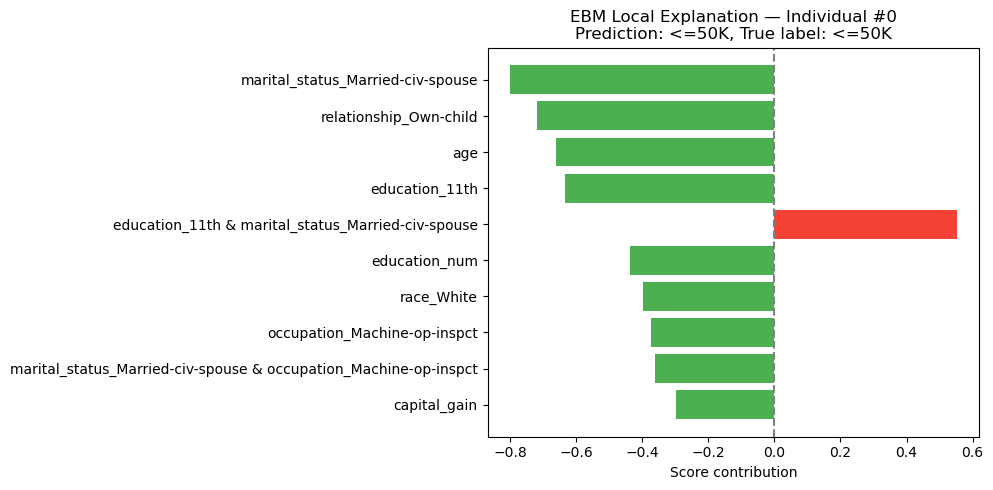

In [22]:
# Local explanation for one individual
ebm_local = ebm.explain_local(X_test.iloc[:1], y_test.iloc[:1])
local_data = ebm_local.data(0)

feat_names = local_data['names']
feat_scores = local_data['scores']

# Sort by absolute contribution
sorted_idx = np.argsort(np.abs(feat_scores))[-10:]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#F44336' if s > 0 else '#4CAF50' for s in np.array(feat_scores)[sorted_idx]]
ax.barh(range(len(sorted_idx)), np.array(feat_scores)[sorted_idx], color=colors)
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feat_names[i] for i in sorted_idx])
ax.axvline(x=0, color='gray', linestyle='--')
ax.set_xlabel('Score contribution')
ax.set_title(f'EBM Local Explanation — Individual #0\n'
             f'Prediction: {">50K" if y_pred_ebm[0] == 1 else "<=50K"}, '
             f'True label: {">50K" if y_test.iloc[0] == 1 else "<=50K"}')
plt.tight_layout()
plt.show()

## 12. Post Hoc Explanations with SHAP (on the Black Box)

Now we switch to the approach **Rudin criticizes**: explaining a black box after the fact. SHAP approximates feature contributions — useful, but not faithful to the model's actual computation.

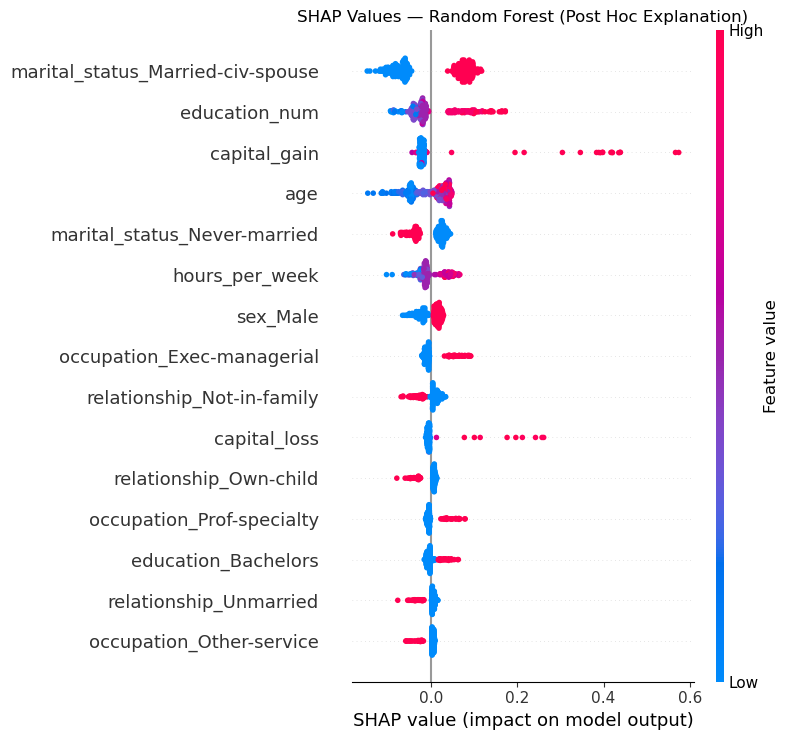

In [23]:
import shap

# SHAP for Random Forest
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test.iloc[:300])  # subset for speed

# Summary plot
shap.summary_plot(shap_values[:, :, 1], X_test.iloc[:300], max_display=15, show=False)
plt.title("SHAP Values — Random Forest (Post Hoc Explanation)")
plt.tight_layout()
plt.show()

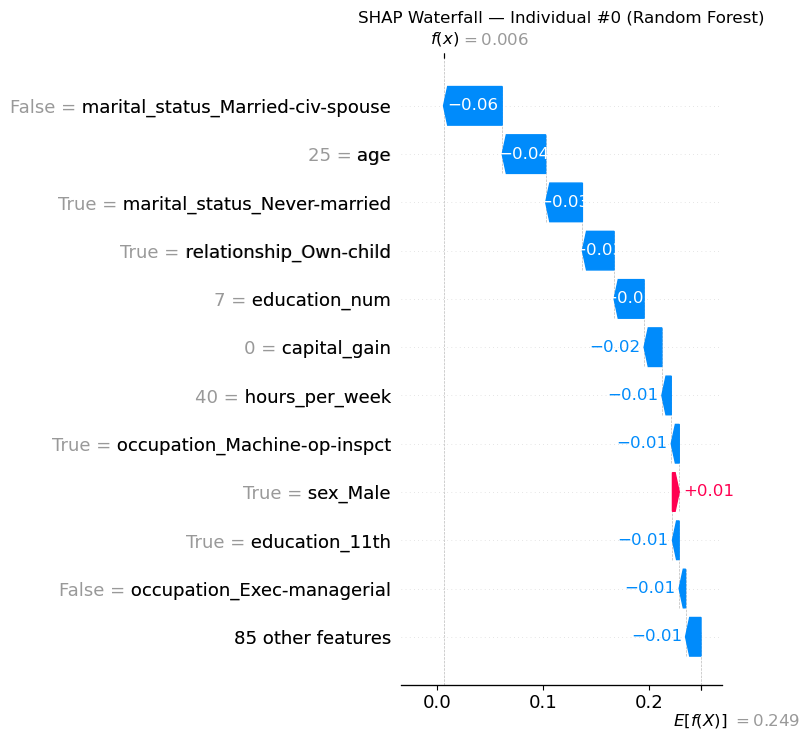

In [24]:
# SHAP waterfall for a single individual
shap_explanation = shap.TreeExplainer(rf)(X_test.iloc[:1])
shap.plots.waterfall(shap_explanation[:, :, 1][0], max_display=12, show=False)
plt.title("SHAP Waterfall — Individual #0 (Random Forest)")
plt.tight_layout()
plt.show()

## Shapash 

Shapash (by MAIF) provides higher-level explainability dashboards and It's fun to play with.

In [25]:
from shapash import SmartExplainer

xpl = SmartExplainer(model=gb)  # Explain the Gradient Boosting model
xpl.compile(x=X_test.iloc[:500], y_target=y_test.iloc[:500])

# Feature importance
xpl.plot.features_importance(max_features=15)

INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x0000016A9833F3D0>


In [26]:
xpl.plot.contribution_plot("age")

In [27]:
xpl.plot.contribution_plot("education_num")